# 하수 드롭아웃 감지 — 파라미터 튜닝 (분석 전용, 데이터셋 미변경)

`sewer_dropout_clean.ipynb`의 감지 규칙 임계값을 실험하는 노트북. **여기서는 저장하지 않음** — 스윕/시각화/사례확인만 하고, 결정한 값(`FLOOR`/`HIGH`/`MAXLEN`)을 `sewer_dropout_clean`에 넣어 재실행한다.

**규칙**: 한 구간이 아래 3조건을 모두 만족하면 '센서 드롭아웃'으로 판정 → 보간 대상.
- `FLOOR` — 바닥값 기준. `level_max_10m ≤ FLOOR` 이면 바닥.
- `HIGH` — 브래킷 기준. 바닥값 런의 직전·직후 bin이 둘 다 `≥ HIGH`.
- `MAXLEN` — 최대 런 길이(10분 bin 수). 그 이하만 보간(긴 런은 선형보간 신뢰도↓).

**공격적**(HIGH↓ / MAXLEN↑) = 더 많이 잡음(오탐↑, 실데이터 훼손 위험). **보수적**(HIGH↑ / MAXLEN↓) = 확실한 것만(미탐↑).

> ⚠️ 원본 `level_max` 복원: 현재 저장본은 이미 `is_dropout` bin이 보간돼 있으므로, 그 bin을 바닥값(0.01)으로 되돌려 원 상태를 재구성해 스캔한다(≤FLOOR 판정에는 영향 없음). 정밀 원자료가 필요하면 1분 raw 재집계로 대체.

In [1]:
import os, sys
while not os.path.exists("scripts/krfont.py") and os.getcwd() != "/":
    os.chdir("..")
sys.path.insert(0, "scripts")
from krfont import set_korean; set_korean()
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

F = "dataset/processed/eda_based/sewer_features_10min.parquet"
df = pd.read_parquet(F, columns=["sewer_sensor_id", "ts10", "level_max_10m", "is_dropout"])
df["ts10"] = pd.to_datetime(df["ts10"])
df = df.sort_values(["sewer_sensor_id", "ts10"]).reset_index(drop=True)

# 원본 level_max 재구성 (이미 보간된 드롭아웃 bin → 바닥값 0.01 로 복원)
lv  = df["level_max_10m"].values.copy()
lv[df["is_dropout"].values == 1] = 0.01
sid = df["sewer_sensor_id"].values
ts  = df["ts10"].values
n   = len(df); TEN = np.timedelta64(10, "m")
print(f"행 {n:,} · 센서 {df['sewer_sensor_id'].nunique()} · 재구성 완료")

행 51,560,086 · 센서 485 · 재구성 완료


## 1. 파라미터화된 감지 함수
`sewer_dropout_clean` 셀 1과 동일 로직. 선택된 런의 위치/길이/브래킷 값을 함께 반환.

In [2]:
def scan(FLOOR=0.02, HIGH=0.3, MAXLEN=12, return_runs=False):
    """드롭아웃 런 감지. runs, bins, sensors 반환. return_runs=True면 상세 DataFrame도."""
    isf = lv <= FLOOR
    chg = np.ones(n, bool); chg[1:] = (sid[1:] != sid[:-1]) | (isf[1:] != isf[:-1])
    rs = np.where(chg)[0]; re = np.append(rs[1:], n); rl = re - rs; rf = isf[rs]
    bidx = rs - 1; aidx = re
    bok = (bidx >= 0) & (sid[np.clip(bidx,0,n-1)] == sid[rs])
    aok = (aidx <  n) & (sid[np.clip(aidx,0,n-1)] == sid[rs])
    adjb = bok & ((ts[rs] - ts[np.clip(bidx,0,n-1)]) == TEN)
    adja = aok & ((ts[np.clip(aidx,0,n-1)] - ts[re-1]) == TEN)
    bval = np.where(bok, lv[np.clip(bidx,0,n-1)], -np.inf)
    aval = np.where(aok, lv[np.clip(aidx,0,n-1)], -np.inf)
    sel = rf & (rl <= MAXLEN) & adjb & adja & (bval >= HIGH) & (aval >= HIGH)
    runs = int(sel.sum()); bins = int(rl[sel].sum())
    sensors = len(np.unique(sid[rs[sel]])) if runs else 0
    if not return_runs:
        return runs, bins, sensors
    rows = pd.DataFrame({
        "sensor": sid[rs[sel]], "start": ts[rs[sel]], "len_bins": rl[sel],
        "before": np.round(bval[sel], 2), "after": np.round(aval[sel], 2)})
    return runs, bins, sensors, rows

r, b, s = scan()
print(f"기본값(H=0.3, len<=12): 런 {r:,} · bins {b:,} ({b/n*100:.3f}%) · 센서 {s}")

기본값(H=0.3, len<=12): 런 4,356 · bins 10,977 (0.021%) · 센서 100


## 2. 임계값 스윕 (HIGH × MAXLEN)

In [3]:
HIGHS = [0.6, 0.5, 0.4, 0.3, 0.2, 0.15]
MAXLENS = [6, 12, 18, 36]   # 1h · 2h · 3h · 6h
rec = []
for H in HIGHS:
    for M in MAXLENS:
        r, b, s = scan(HIGH=H, MAXLEN=M)
        rec.append({"HIGH": H, "MAXLEN": M, "시간": f"{M*10//60}h" if M*10%60==0 else f"{M*10}m",
                    "런": r, "bins": b, "pct": round(b/n*100, 4), "센서": s})
sweep = pd.DataFrame(rec)
pivot_bins = sweep.pivot(index="HIGH", columns="MAXLEN", values="bins")
print("보정 bins 수 (행=HIGH, 열=MAXLEN bins):")
print(pivot_bins.to_string())
sweep

보정 bins 수 (행=HIGH, 열=MAXLEN bins):
MAXLEN     6      12     18     36
HIGH                              
0.15    14520  19056  21607  29538
0.20    12060  15786  18011  25054
0.30     8140  10977  12605  18447
0.40     7524  10152  11662  17134
0.50     6663   8861  10119  14773
0.60     6402   8495   9692  14047


,HIGH,MAXLEN,시간,런,bins,pct,센서
0,0.60,6,1h,3196,6402,0.0124,78
1,0.60,12,2h,3435,8495,0.0165,81
2,0.60,18,3h,3514,9692,0.0188,82
3,0.60,36,6h,3677,14047,0.0272,83
4,0.50,6,1h,3308,6663,0.0129,81
5,0.50,12,2h,3559,8861,0.0172,84
6,0.50,18,3h,3642,10119,0.0196,85
7,0.50,36,6h,3816,14773,0.0287,86
8,0.40,6,1h,3695,7524,0.0146,87
9,0.40,12,2h,3994,10152,0.0197,90


## 3. 트레이드오프 시각화

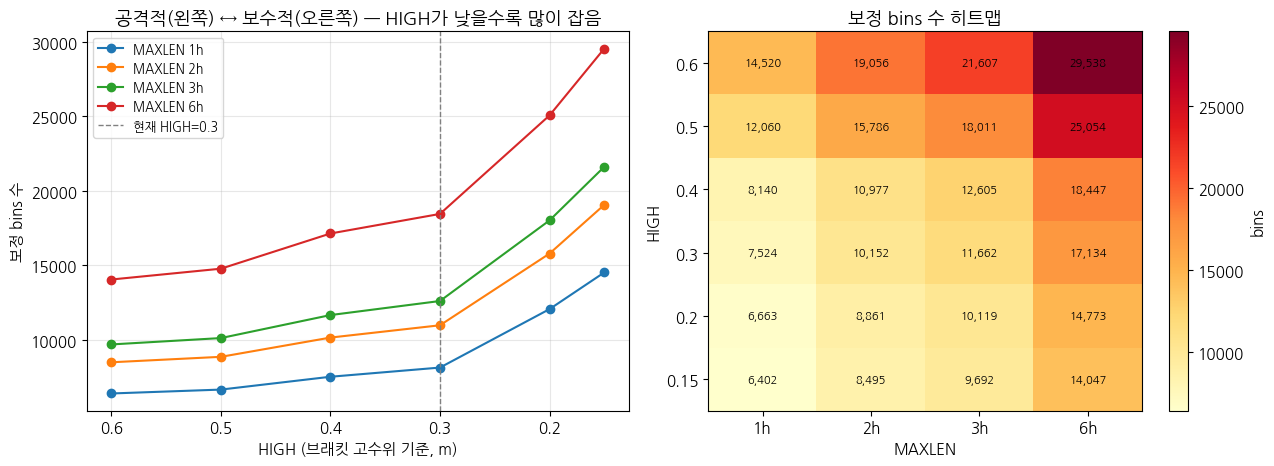

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
# (좌) HIGH에 따른 보정 bins (MAXLEN별 선)
for M in MAXLENS:
    d = sweep[sweep["MAXLEN"] == M].sort_values("HIGH")
    ax[0].plot(d["HIGH"], d["bins"], "o-", label=f"MAXLEN {M*10//60}h")
ax[0].axvline(0.3, color="gray", ls="--", lw=1, label="현재 HIGH=0.3")
ax[0].set_xlabel("HIGH (브래킷 고수위 기준, m)"); ax[0].set_ylabel("보정 bins 수")
ax[0].set_title("공격적(왼쪽) ↔ 보수적(오른쪽) — HIGH가 낮을수록 많이 잡음")
ax[0].invert_xaxis(); ax[0].legend(fontsize=9); ax[0].grid(alpha=0.3)
# (우) 히트맵
im = ax[1].imshow(pivot_bins.values, aspect="auto", cmap="YlOrRd")
ax[1].set_xticks(range(len(MAXLENS))); ax[1].set_xticklabels([f"{m*10//60}h" for m in MAXLENS])
ax[1].set_yticks(range(len(HIGHS))); ax[1].set_yticklabels(HIGHS)
ax[1].set_xlabel("MAXLEN"); ax[1].set_ylabel("HIGH")
ax[1].set_title("보정 bins 수 히트맵")
for i in range(len(HIGHS)):
    for j in range(len(MAXLENS)):
        ax[1].text(j, i, f"{pivot_bins.values[i,j]:,}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax[1], label="bins")
plt.tight_layout(); plt.show()

## 4. 사례 확인 — 선택한 임계에서 잡히는 런을 직접 눈으로
특히 **공격적 설정에서 새로 잡히는 런**이 진짜 드롭아웃인지, 아니면 실제 저유량 변동인지 확인하는 용도.
`before`/`after`가 서로 비슷하고 높으면 드롭아웃 신뢰↑.

In [5]:
# 예: 현재값 vs 공격적(H=0.15)에서 '새로 추가되는' 런 비교
_, _, _, cur = scan(HIGH=0.3, MAXLEN=12, return_runs=True)
_, _, _, agg = scan(HIGH=0.15, MAXLEN=12, return_runs=True)
key = ["sensor", "start"]
new = agg.merge(cur[key], on=key, how="left", indicator=True)
new = new[new["_merge"] == "left_only"].drop(columns="_merge")
print(f"공격적(H=0.15)에서 새로 추가되는 런: {len(new):,}개")
print("before/after 분포 (낮을수록 실저유량일 가능성↑):")
print(new[["before", "after"]].describe().round(2).to_string())
print("\n샘플 12개:"); print(new.head(12).to_string(index=False))

공격적(H=0.15)에서 새로 추가되는 런: 3,630개
before/after 분포 (낮을수록 실저유량일 가능성↑):
        before    after
count  3630.00  3630.00
mean      0.25     0.25
std       0.18     0.18
min       0.15     0.15
25%       0.19     0.19
50%       0.23     0.23
75%       0.26     0.26
max       2.27     2.70

샘플 12개:
 sensor               start  len_bins  before  after
04-0002 2022-12-13 09:30:00         1    0.22   0.22
04-0004 2022-12-13 09:30:00         1    0.16   0.15
05-0004 2023-10-14 17:50:00         1    0.19   0.16
05-0004 2023-10-14 18:50:00         1    0.17   0.19
05-0004 2023-10-14 20:40:00         7    0.25   0.30
05-0004 2023-10-15 19:10:00         1    0.46   0.19
05-0004 2023-10-15 19:30:00         8    0.19   0.39
05-0005 2025-06-05 16:00:00         1    0.16   0.20
05-0005 2025-06-05 16:20:00         2    0.20   0.21
05-0005 2025-06-05 18:10:00         1    0.20   0.20
05-0005 2025-06-07 12:50:00         2    0.20   0.19
05-0005 2025-06-07 14:20:00         1    0.19   0.19


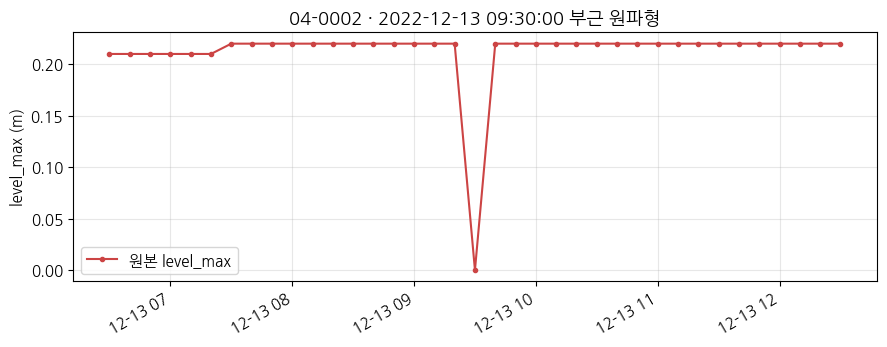

In [6]:
# 특정 런을 파형으로 확인 (센서·시각 지정)
def plot_window(sensor, center_ts, hours=3):
    c = pd.Timestamp(center_ts)
    m = (df["sewer_sensor_id"] == sensor) & (df["ts10"] >= c - pd.Timedelta(hours=hours)) & (df["ts10"] <= c + pd.Timedelta(hours=hours))
    d = df[m].sort_values("ts10")
    orig = lv[d.index]   # 재구성 원본
    fig, ax = plt.subplots(figsize=(9, 3.6))
    ax.plot(d["ts10"], orig, "o-", ms=3, color="#c44", label="원본 level_max")
    ax.set_title(f"{sensor} · {center_ts} 부근 원파형"); ax.set_ylabel("level_max (m)")
    ax.legend(); ax.grid(alpha=0.3); fig.autofmt_xdate(); plt.tight_layout(); plt.show()

if len(new):
    ex = new.iloc[0]
    plot_window(ex["sensor"], ex["start"])

## 5. 적용 방법
이 노트북에서 결정한 `FLOOR`/`HIGH`/`MAXLEN` 을 `notebooks/01_preprocessing/sewer_dropout_clean.ipynb` 셀 1의 상수에 넣고 재실행하면 데이터셋에 반영된다(이 노트북은 저장하지 않음).

현재 채택값: `FLOOR=0.02, HIGH=0.3, MAXLEN=12` (명백한 케이스는 모두 포착 + 애매한 저수위 0.15~0.3은 미개입 = 실데이터 훼손 최소).